# **PROYECTO: ANÁLISIS DE EXPLORATORIO DE DATOS**

**Acciones realizadas**

- Añadido heatmap de correlación sobre `df_encoded` (se excluye `visit_date`).
- Aplicado `LabelEncoder` a variables categóricas y guardado en `df_encoded`.
- Añadidos scatter plots de cada variable numérica vs `readmission_risk`.
- Añadidos scatter plots coloreados (hue) por columnas categóricas detectadas (ej. `age_group`, `gender`, `department`) cuando existen.
- Añadidos boxplots de variables categóricas vs `readmission_risk`.
- Añadidos countplots para variables categóricas; actualizado para evitar el FutureWarning de Seaborn (no pasar `palette` sin `hue`).

Una vez visto el ***Módulo 3: Introducción al Análisis de Datos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar todo el proceso que involucra el **análisis de datos** donde el tema a emplear es libre ya que dependerá del **dataset a escoger**. Cada **proceso del análisis** deberá ser mostrado en este notebook:

*   **Recopilación de datos.**
*   **Limpieza de datos.**
*   **Exploración de datos.**
*   **Visualización de datos.**

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('./data/healthcare_patient_analytics_seaborn.csv')
df.head()


,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.8,59151.0,59.0,0.12
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.1,30272.0,97.0,0.11
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.9,67498.0,60.0,0.19
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.0,29896.0,51.0,0.47
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.0,36208.0,60.0,0.40


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           5000 non-null   int64  
 1   visit_date           5000 non-null   object 
 2   age_group            5000 non-null   object 
 3   gender               5000 non-null   object 
 4   region               5000 non-null   object 
 5   department           5000 non-null   object 
 6   treatment_type       5000 non-null   object 
 7   visit_type           5000 non-null   object 
 8   length_of_stay_days  5000 non-null   float64
 9   treatment_cost       5000 non-null   float64
 10  recovery_score       5000 non-null   float64
 11  readmission_risk     5000 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 468.9+ KB


In [8]:
df.describe()

,patient_id,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,4.059660,54915.471800,74.718800,0.280966
std,1443.520003,1.928847,19481.160487,11.870481,0.157178
min,1.000000,0.000000,746.000000,33.000000,0.010000
25%,1250.750000,2.700000,41244.750000,67.000000,0.160000
50%,2500.500000,4.000000,55123.500000,75.000000,0.260000
75%,3750.250000,5.400000,68012.000000,83.000000,0.380000
max,5000.000000,11.900000,119307.000000,100.000000,0.840000


## EDA

### Variables numéricas

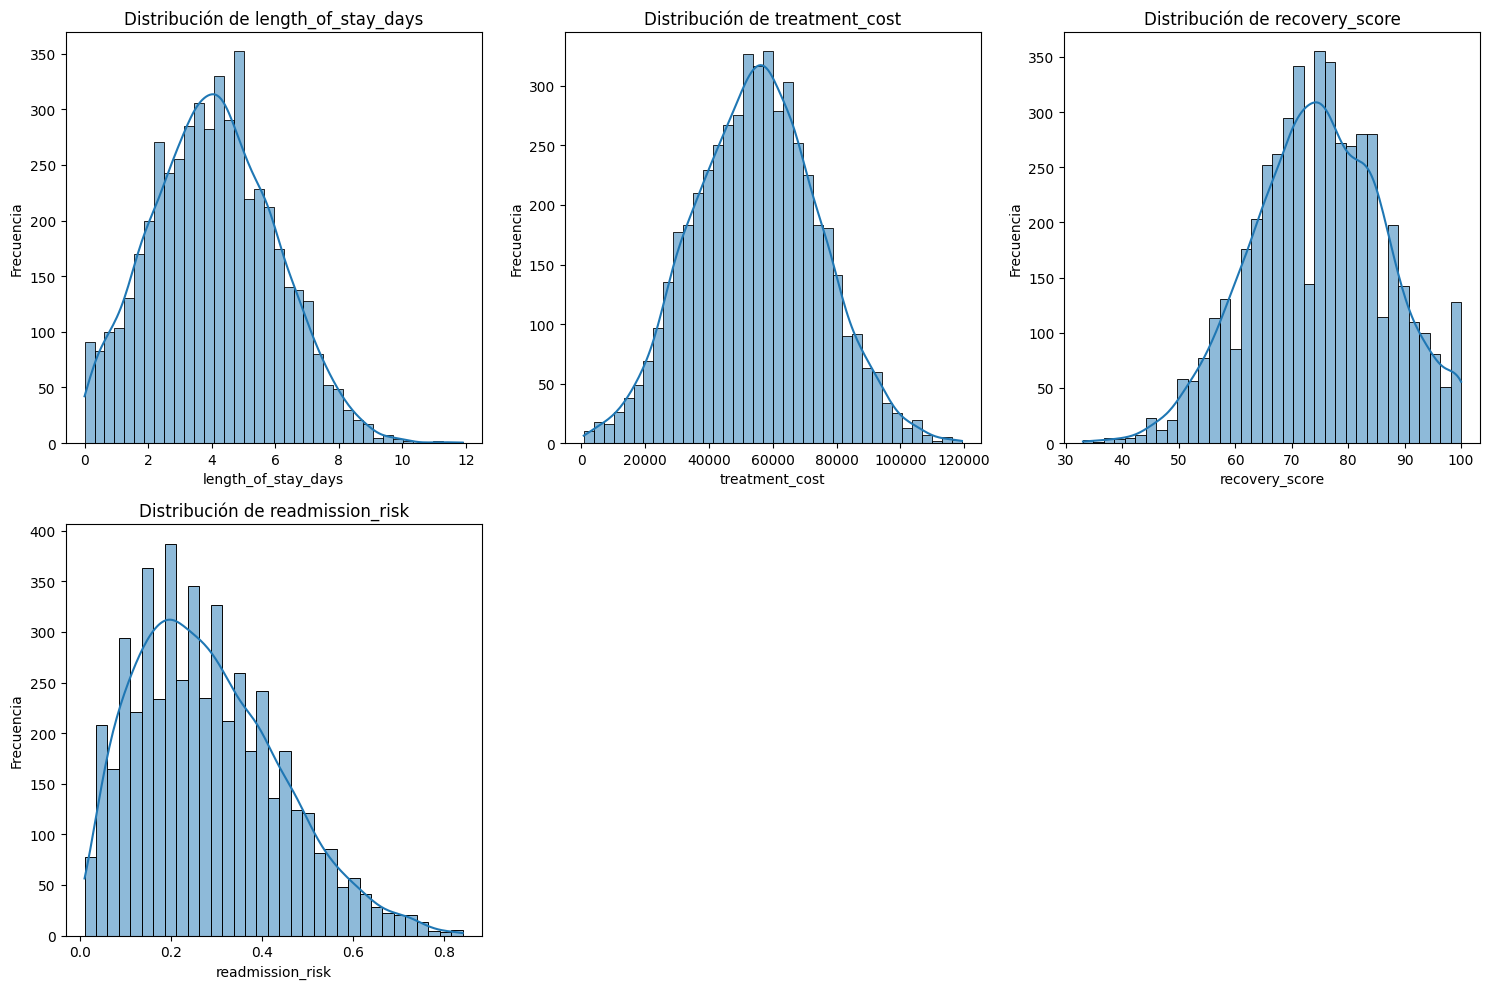

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas numéricas (excluyendo 'patient_id')
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'patient_id' in numeric_cols:
    numeric_cols.remove('patient_id')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)  # Ajusta el número de filas y columnas según sea necesario
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


In [14]:
from sklearn.preprocessing import LabelEncoder

# Identificar columnas categóricas
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Excluir 'visit_date' si es una columna de fecha/hora que se manejará por separado o se omitirá
# En este caso, 'visit_date' es tipo object pero representa una fecha. Para la correlación directa
# con otras variables, es mejor omitirla o extraer características numéricas de ella (ej. mes, día).
# Por ahora, la excluiremos de la codificación directa si no se especifica lo contrario.
if 'visit_date' in categorical_cols:
    categorical_cols.remove('visit_date')

# Crear una copia del DataFrame para no modificar el original directamente si no se desea
df_encoded = df.copy()

# Aplicar Label Encoding a las columnas categóricas
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("DataFrame después de la codificación de variables categóricas:")
print(df_encoded.head())
print("\nTipos de datos actualizados:")
df_encoded.info()

DataFrame después de la codificación de variables categóricas:
   patient_id           visit_date  age_group  gender  region  department  \
0           1  2022-01-01 00:00:00          1       1       3           1   
1           2  2022-01-01 01:00:00          3       0       3           3   
2           3  2022-01-01 02:00:00          2       1       2           4   
3           4  2022-01-01 03:00:00          1       0       1           2   
4           5  2022-01-01 04:00:00          0       0       1           2   

   treatment_type  visit_type  length_of_stay_days  treatment_cost  \
0               0           0                  5.8         59151.0   
1               2           1                  5.1         30272.0   
2               1           1                  7.9         67498.0   
3               0           1                  5.0         29896.0   
4               3           1                  0.0         36208.0   

   recovery_score  readmission_risk  
0            59

**Codificación de variables categóricas**

Se aplicó `LabelEncoder` a las columnas categóricas (excluyendo `visit_date`) y se guardó el resultado en `df_encoded`. Esto permite usar variables categóricas en análisis numéricos y en la matriz de correlación.

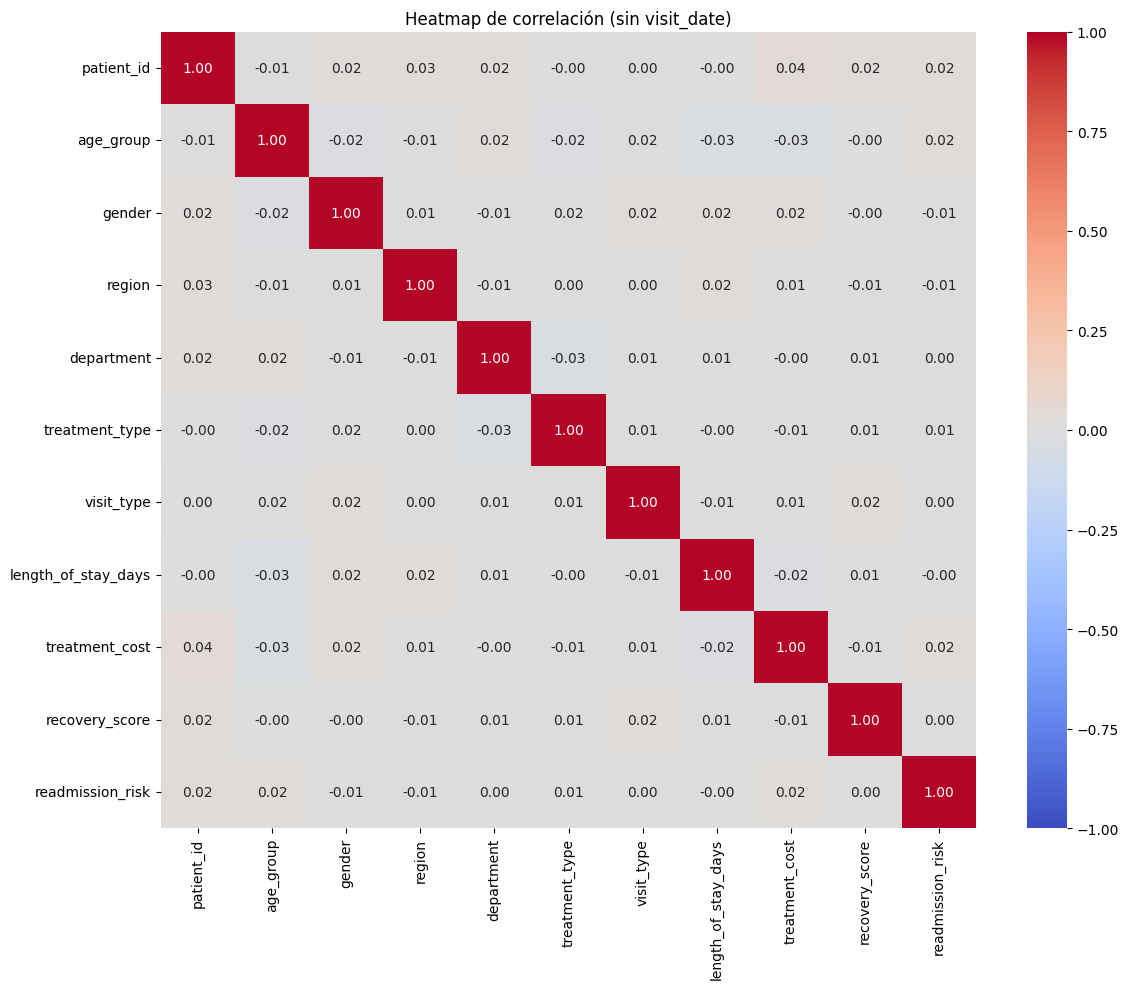

In [15]:
# Heatmap de correlación excluyendo 'visit_date'
import matplotlib.pyplot as plt
import seaborn as sns
        
# Preparar DataFrame para correlación: eliminar 'visit_date' si existe
corr_df = df_encoded.drop(columns=['visit_date'], errors='ignore')
        
# Calcular matriz de correlación
correlationmatrix = corr_df.corr()
        
plt.figure(figsize=(12,10))
sns.heatmap(correlationmatrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=False)
plt.title('Heatmap de correlación (sin visit_date)')
plt.tight_layout()
plt.show()

**Heatmap de correlación**

Se generó un heatmap de correlación sobre `df_encoded` (se excluye `visit_date`) para identificar relaciones lineales entre variables numéricas.

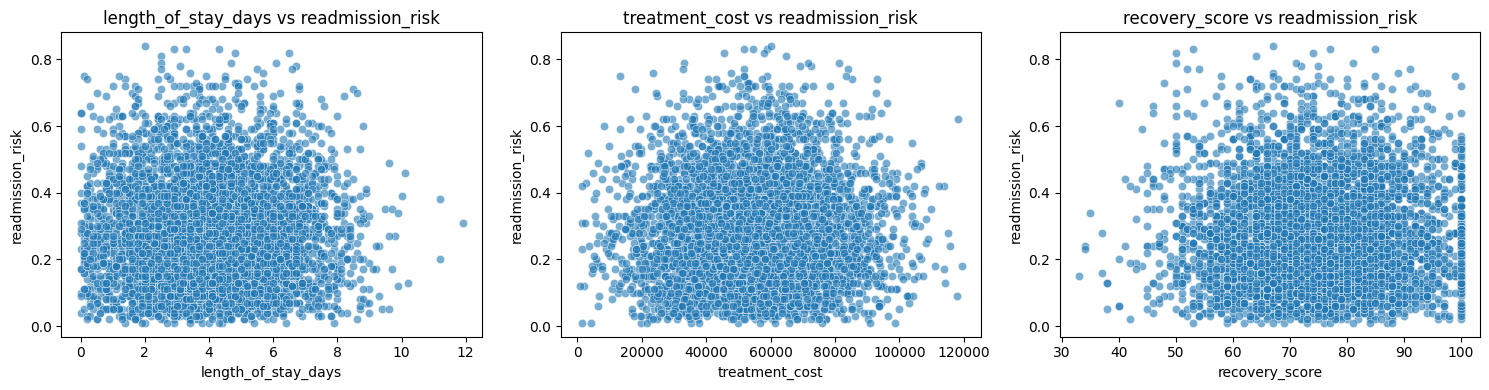

In [16]:
# Scatter plots: cada variable numérica vs `readmission_risk` (sobre `df`)
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas numéricas
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Excluir columnas no pertinentes
for exc in ['patient_id', 'visit_date']:
    if exc in numeric_cols:
        numeric_cols.remove(exc)

# Excluir la variable objetivo de la lista para no graficarla contra sí misma
if 'readmission_risk' in numeric_cols:
    numeric_cols.remove('readmission_risk')

n = len(numeric_cols)
if n == 0:
    print('No hay variables numéricas disponibles para graficar contra readmission_risk.')
else:
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(numeric_cols):
        ax = axes_flat[i]
        sns.scatterplot(data=df, x=col, y='readmission_risk', ax=ax, alpha=0.6)
        ax.set_title(f'{col} vs readmission_risk')

    # Ocultar subplots sobrantes
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()


**Scatter plots (numéricas vs readmission_risk)**

Se añadieron scatter plots para cada variable numérica frente a `readmission_risk` para evaluar relaciones y dispersión.

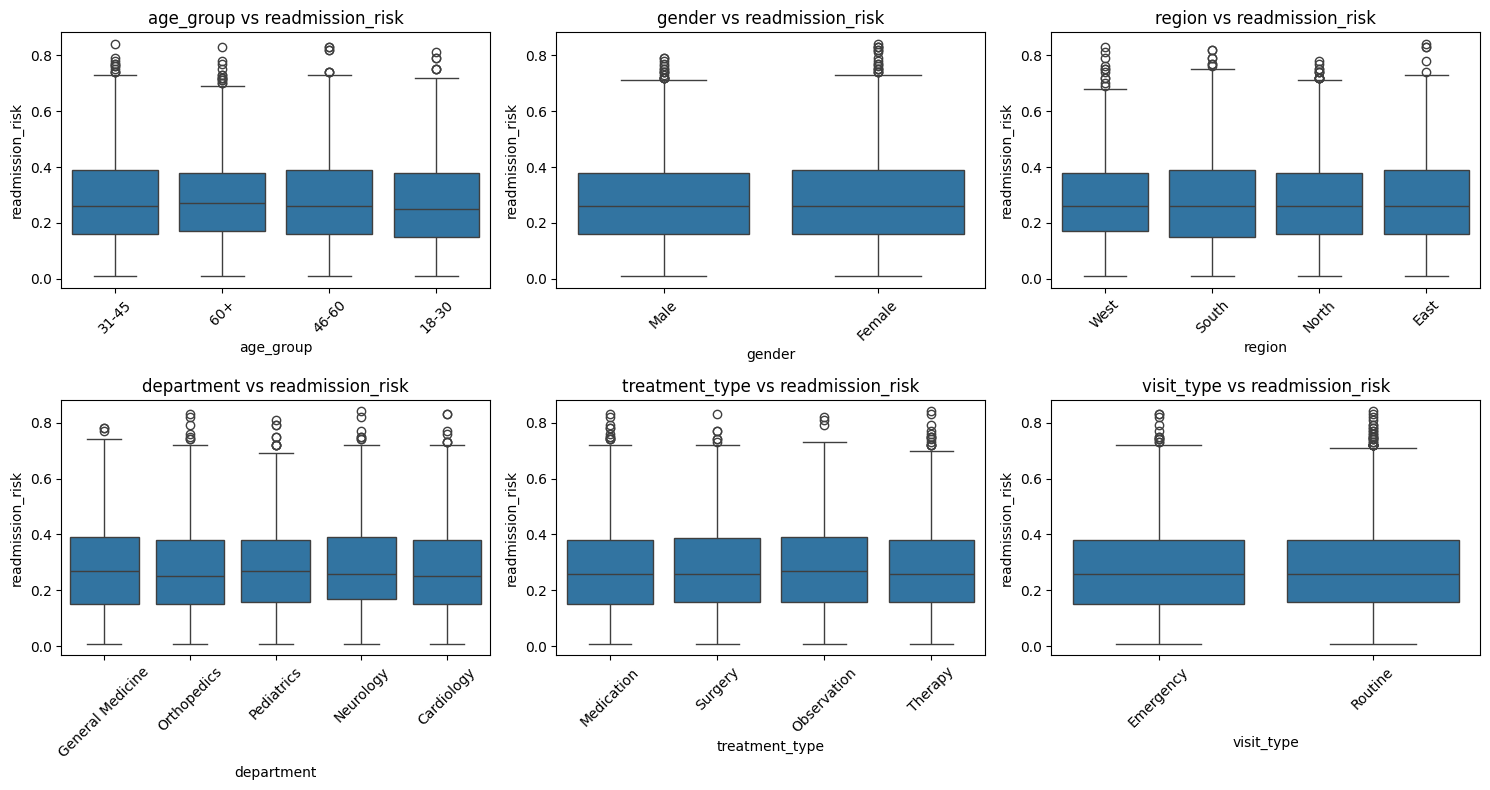

In [17]:
# Boxplots: variables categóricas vs `readmission_risk` (sobre `df`)
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas categóricas
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Excluir columnas no pertinentes
for exc in ['visit_date', 'patient_id']:
    if exc in cat_cols:
        cat_cols.remove(exc)

# Asegurar que la variable objetivo no esté en la lista
if 'readmission_risk' in cat_cols:
    cat_cols.remove('readmission_risk')

n = len(cat_cols)
if n == 0:
    print('No hay variables categóricas para graficar contra readmission_risk.')
else:
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(cat_cols):
        ax = axes_flat[i]
        try:
            sns.boxplot(data=df, x=col, y='readmission_risk', ax=ax)
            ax.set_title(f'{col} vs readmission_risk')
            ax.set_xlabel(col)
            ax.set_ylabel('readmission_risk')
            for tick in ax.get_xticklabels():
                tick.set_rotation(45)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {e}', ha='center')
            ax.set_title(f'{col} (error)')

    # Ocultar subplots sobrantes
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()


**Boxplots categóricos vs readmission_risk**

Se generaron boxplots para cada variable categórica frente a `readmission_risk` para comparar distribuciones por categoría.

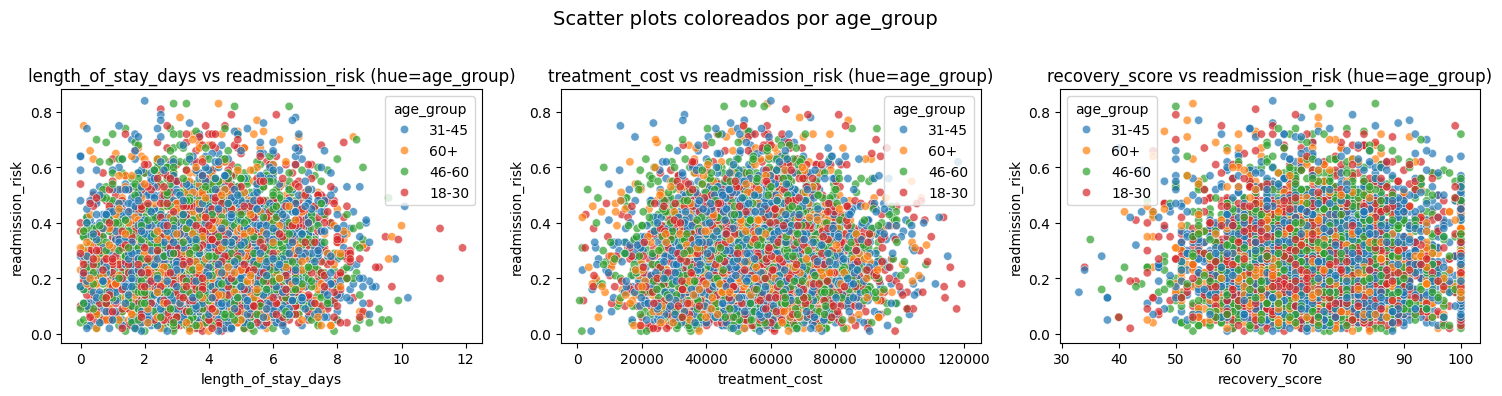

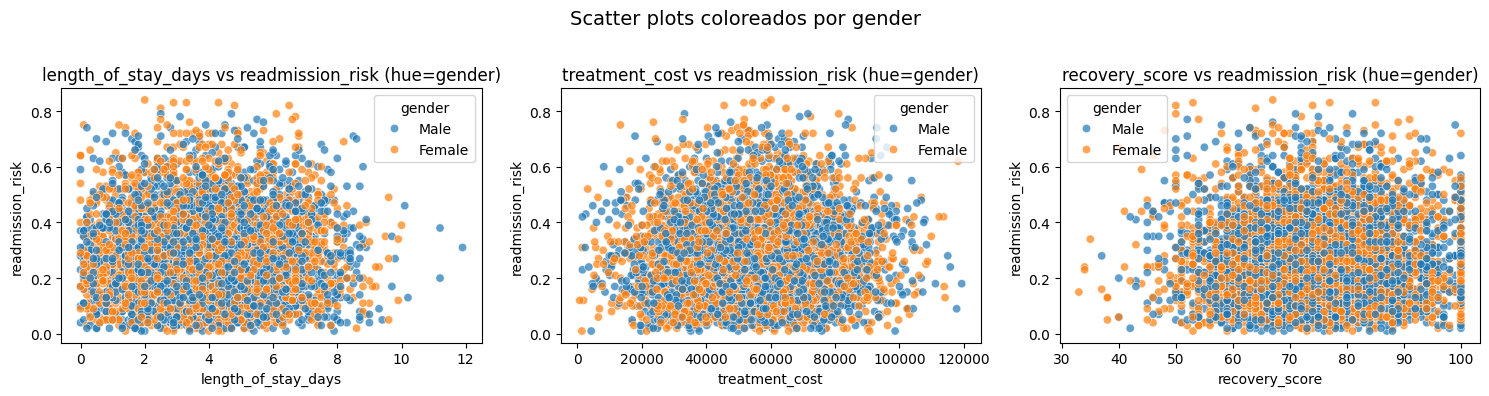

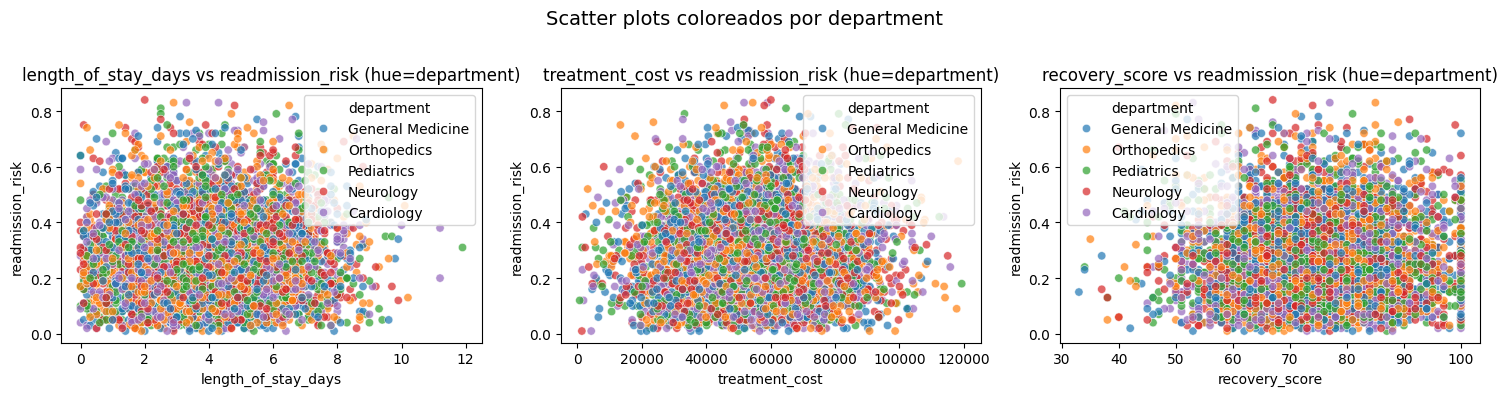

In [18]:
# Scatter plots numéricas vs `readmission_risk` coloreadas por categorías (age_group, gender, department)
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Posibles nombres de las columnas categóricas (variantes comunes)
candidate_hues = ['age_group', 'age group', 'age_group_bucket', 'age_group_label',
                  'gender', 'sex', 'genero', 'department', 'dept', 'department_name']

# Detectar cuáles existen en el DataFrame
available_hues = [col for col in candidate_hues if col in df.columns]
# Mantener nombres únicos y en el orden preferido
seen = set()
available_hues = [x for x in available_hues if not (x in seen or seen.add(x))]

# Identificar columnas numéricas
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for exc in ['patient_id', 'visit_date', 'readmission_risk']:
    if exc in numeric_cols:
        numeric_cols.remove(exc)

if len(numeric_cols) == 0:
    print('No hay variables numéricas para graficar contra readmission_risk.')
elif len(available_hues) == 0:
    print('No se encontraron columnas de hue entre las candidatas: ', candidate_hues)
else:
    for hue in available_hues:
        n = len(numeric_cols)
        ncols = 3
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4))
        axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

        for i, col in enumerate(numeric_cols):
            ax = axes_flat[i]
            try:
                sns.scatterplot(data=df, x=col, y='readmission_risk', hue=hue, ax=ax, alpha=0.7, palette='tab10')
                ax.set_title(f'{col} vs readmission_risk (hue={hue})')
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {e}', ha='center')
                ax.set_title(f'{col} (error)')

        # Ocultar subplots sobrantes
        for j in range(n, len(axes_flat)):
            axes_flat[j].set_visible(False)

        plt.suptitle(f'Scatter plots coloreados por {hue}', fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


**Scatter plots coloreados por categoría (hue)**

Se añadieron scatter plots numéricos vs `readmission_risk` coloreados por columnas categóricas detectadas (ej. `age_group`, `gender`, `department`) cuando existen.

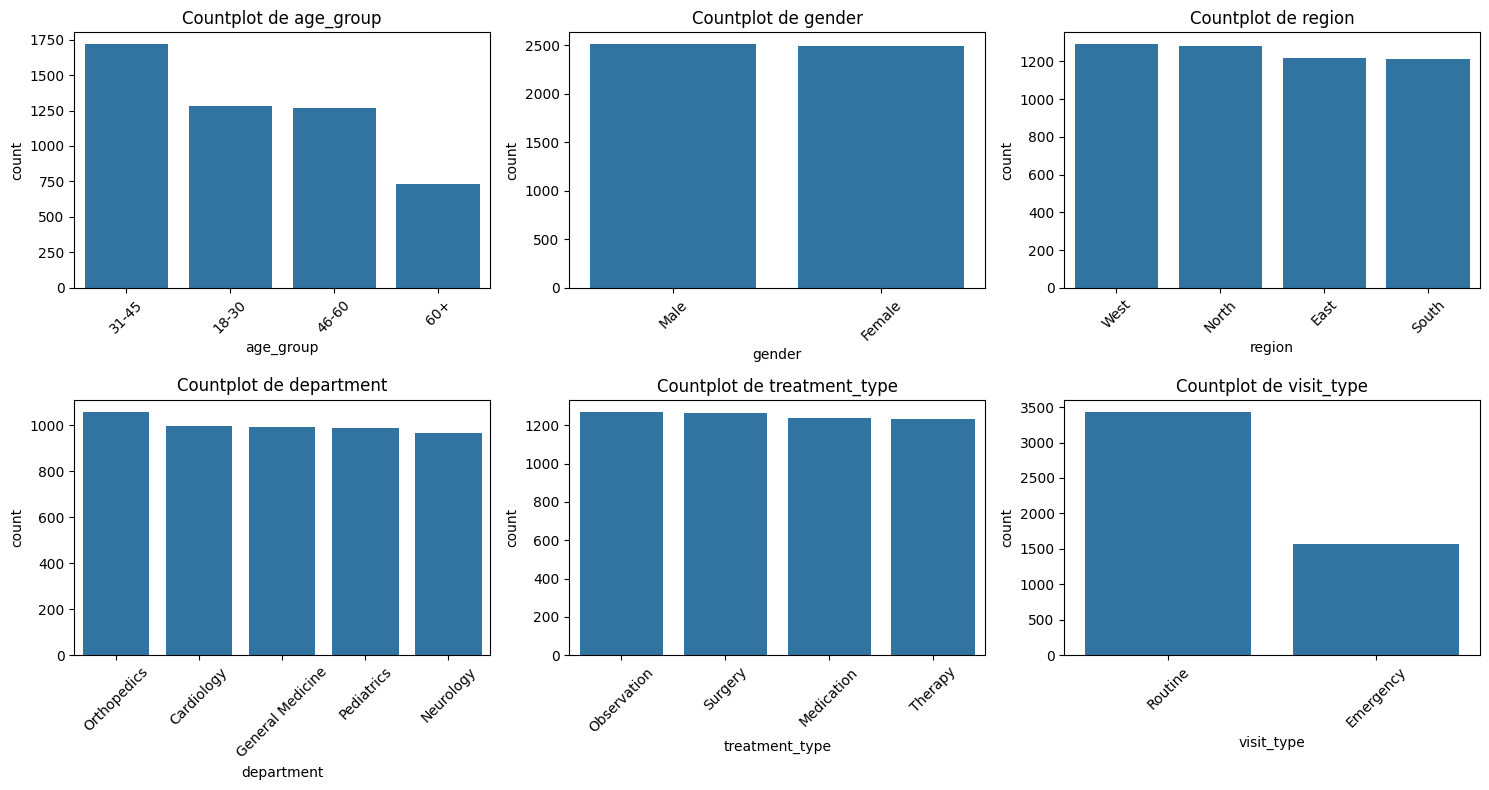

In [20]:
# Countplots para variables categóricas (sin pasar `palette` para evitar FutureWarning)
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas categóricas
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Excluir columnas no pertinentes
for exc in ['visit_date', 'patient_id', 'readmission_risk']:
    if exc in cat_cols:
        cat_cols.remove(exc)

n = len(cat_cols)
if n == 0:
    print('No hay variables categóricas para graficar.')
else:
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(cat_cols):
        ax = axes_flat[i]
        try:
            order = df[col].value_counts().index
            # No pasar `palette` cuando no hay `hue` para evitar FutureWarning
            sns.countplot(data=df, x=col, order=order, ax=ax)
            ax.set_title(f'Countplot de {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('count')
            for tick in ax.get_xticklabels():
                tick.set_rotation(45)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {e}', ha='center')
            ax.set_title(f'{col} (error)')

    # Ocultar subplots sobrantes
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()


**Countplots de variables categóricas**

Se generaron countplots para cada variable categórica (excluyendo `visit_date`, `patient_id` y `readmission_risk`). Se actualizó la llamada para evitar el FutureWarning de Seaborn (no pasar `palette` sin `hue`).